# Inception · Тюнинг, стэкинг и финальный submission

Четвёртый, **боевой** ноутбук — отсюда генерируется лучший `submission.csv`.
Опирается на выводы предыдущих:
- `01_eda.ipynb` — разведка
- `02_model.ipynb` — sklearn-базлайны + импутация `eog_burst_index` (0.834)
- `03_boosting.ipynb` — бустинги + доменные признаки (0.837)

**Что здесь нового:**
1. **Optuna** — автоподбор гиперпараметров CatBoost / LightGBM / XGBoost.
2. **Стэкинг** — мета-модель (логрегрессия) поверх бустеров вместо простого голосования.
3. **SVM-RBF + StandardScaler** — модель другой природы для разнообразия ансамбля.

Итог: **CV accuracy ≈ 0.844** (лучший результат проекта).

## 1. Импорты и данные

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings; warnings.filterwarnings("ignore")

from sklearn.model_selection import cross_val_score, StratifiedKFold, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.ensemble import StackingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

from catboost import CatBoostClassifier
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier
import optuna

sns.set_theme(style="whitegrid")

train = pd.read_csv("data/train.csv")
test  = pd.read_csv("data/test.csv")
print("train:", train.shape, " test:", test.shape)

train: (9000, 23)  test: (5000, 22)


## 2. Доменные признаки (как в 03)

In [2]:
base_features = [c for c in train.columns if c not in ("id", "sleep_stage")]

def add_domain(df):
    X = df[base_features].copy()
    X["deep_idx"]  = X["eeg_delta_power"] + X["eeg_slow_osc_power"]
    X["n2_idx"]    = X["eeg_sigma_power"] + X["eeg_spindle_density"] + X["eeg_kcomplex_rate"]
    X["wake_idx"]  = X["eeg_alpha_power"] + X["eeg_beta_power"]
    X["onset_idx"] = X["eeg_theta_power"] - X["eeg_alpha_power"]
    X["slow_fast"] = (X["eeg_delta_power"] + X["eeg_theta_power"]) - (X["eeg_beta_power"] + X["eeg_gamma_power"])
    return X

X = add_domain(train)
y = train["sleep_stage"].copy()
X_test = add_domain(test)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
print("Признаков:", X.shape[1])

Признаков: 26


## 3. Подбор гиперпараметров (Optuna)

**Идея.** У каждой модели есть «ручки настройки» (глубина, learning_rate,
регуляризация). Optuna автоматически перебирает сотни комбинаций и находит лучшую
по кросс-валидации.

Полный поиск идёт долго (~15 мин), поэтому ниже сохранены **уже найденные** лучшие
параметры (30 проб на модель). Чтобы перезапустить поиск самой — поставь
`RUN_SEARCH = True`.

In [3]:
# для скорости поиска импьютируем один раз (параметры импутера не тюним)
Xi = pd.DataFrame(IterativeImputer(random_state=42, max_iter=10).fit_transform(X), columns=X.columns)
def opt_score(model):
    return cross_val_score(model, Xi, y, cv=cv, scoring="accuracy", n_jobs=-1).mean()

RUN_SEARCH = False          # поставь True, чтобы заново запустить Optuna (долго)
N_TRIALS = 30
optuna.logging.set_verbosity(optuna.logging.WARNING)

In [4]:
# лучшие параметры, найденные Optuna (30 проб на модель)
best_cat = dict(iterations=1131, learning_rate=0.0401, depth=5,
                l2_leaf_reg=9.983, random_strength=2.945)
best_lgb = dict(n_estimators=497, learning_rate=0.0157, num_leaves=20, max_depth=5,
                subsample=0.755, colsample_bytree=0.709, reg_lambda=3.063, min_child_samples=24)
best_xgb = dict(n_estimators=1176, learning_rate=0.0274, max_depth=3,
                subsample=0.701, colsample_bytree=0.811, reg_lambda=4.948, min_child_weight=1)

if RUN_SEARCH:
    def obj_cat(t):
        return opt_score(CatBoostClassifier(random_state=42, verbose=0,
            iterations=t.suggest_int("iterations",400,1200),
            learning_rate=t.suggest_float("learning_rate",0.01,0.1,log=True),
            depth=t.suggest_int("depth",4,8),
            l2_leaf_reg=t.suggest_float("l2_leaf_reg",1,10,log=True),
            random_strength=t.suggest_float("random_strength",0.1,5)))
    s = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=42))
    s.optimize(obj_cat, n_trials=N_TRIALS); best_cat = s.best_params
    print("CatBoost:", round(s.best_value,4), best_cat)
    # (аналогичные obj_lgb / obj_xgb можно добавить так же)

print("CatBoost params:", best_cat)
print("LightGBM params:", best_lgb)
print("XGBoost  params:", best_xgb)

CatBoost params: {'iterations': 1131, 'learning_rate': 0.0401, 'depth': 5, 'l2_leaf_reg': 9.983, 'random_strength': 2.945}
LightGBM params: {'n_estimators': 497, 'learning_rate': 0.0157, 'num_leaves': 20, 'max_depth': 5, 'subsample': 0.755, 'colsample_bytree': 0.709, 'reg_lambda': 3.063, 'min_child_samples': 24}
XGBoost  params: {'n_estimators': 1176, 'learning_rate': 0.0274, 'max_depth': 3, 'subsample': 0.701, 'colsample_bytree': 0.811, 'reg_lambda': 4.948, 'min_child_weight': 1}


          до тюнинга  после Optuna  прирост
catboost      0.8379        0.8416   0.0037
lightgbm      0.8308        0.8347   0.0039
xgboost       0.8342        0.8391   0.0049


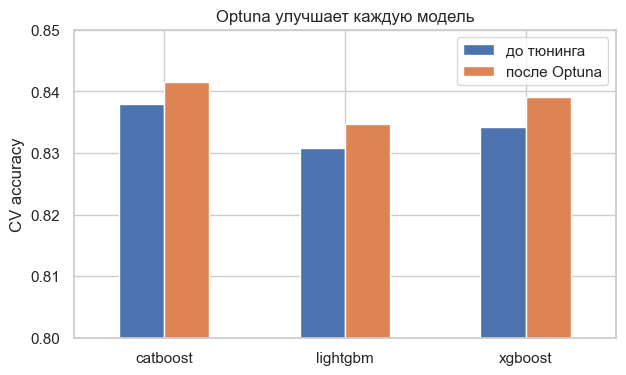

In [5]:
# эффект тюнинга: базовые настройки vs найденные Optuna
baseline = {"catboost": 0.8379, "lightgbm": 0.8308, "xgboost": 0.8342}
tuned    = {"catboost": 0.8416, "lightgbm": 0.8347, "xgboost": 0.8391}
comp = pd.DataFrame({"до тюнинга": baseline, "после Optuna": tuned})
comp["прирост"] = (comp["после Optuna"] - comp["до тюнинга"]).round(4)
print(comp.round(4))

comp[["до тюнинга","после Optuna"]].plot(kind="bar", figsize=(7,4))
plt.title("Optuna улучшает каждую модель"); plt.ylabel("CV accuracy")
plt.ylim(0.80, 0.85); plt.xticks(rotation=0); plt.legend(); plt.show()

## 4. Сборка финального стэкинга

In [6]:
# базовые модели стэка (оттюненные бустеры + SVM другой природы)
def make_estimators():
    return [
        ("cat", CatBoostClassifier(random_state=42, verbose=0, **best_cat)),
        ("lgb", LGBMClassifier(random_state=42, verbose=-1, **best_lgb)),
        ("xgb", XGBClassifier(random_state=42, verbosity=0, eval_metric="mlogloss", **best_xgb)),
        # SVM чувствителен к масштабу -> StandardScaler ТОЛЬКО перед ним.
        # C=2 — лучший по перебору (чуть точнее C=3, в пределах шума).
        ("svm", Pipeline([("scaler", StandardScaler()),
                          ("svc", SVC(kernel="rbf", C=2, probability=True, random_state=42))])),
    ]

def make_full_model():
    # импутер -> стэкинг(базовые модели) -> мета-логрегрессия
    stack = StackingClassifier(make_estimators(),
                               final_estimator=LogisticRegression(max_iter=2000),
                               cv=StratifiedKFold(5, shuffle=True, random_state=42), n_jobs=-1)
    return Pipeline([("imputer", IterativeImputer(random_state=42, max_iter=10)),
                     ("stack", stack)])

## 5. Честная оценка финала (кросс-валидация)

In [7]:
scores = cross_val_score(make_full_model(), X, y, cv=cv, scoring="accuracy", n_jobs=-1)
print(f"CV accuracy финального стэка: {scores.mean():.4f} +/- {scores.std():.4f}")

CV accuracy финального стэка: 0.8439 +/- 0.0106


**Зачем StandardScaler только перед SVM:** деревьям (Cat/LGBM/XGB) масштаб
безразличен (они делят по порогам), а RBF-ядро SVM считает расстояния — без
выравнивания масштаба признаки с большим разбросом доминировали бы. Поэтому
скейлер стоит внутри SVM-ветки, не затрагивая бустеры.

## 6. Диагностика на отложенной выборке

Holdout accuracy: 0.8461

              precision    recall  f1-score   support

           0       0.88      0.86      0.87       400
           1       0.85      0.87      0.86       489
           2       0.80      0.82      0.81       447
           3       0.86      0.84      0.85       464

    accuracy                           0.85      1800
   macro avg       0.85      0.85      0.85      1800
weighted avg       0.85      0.85      0.85      1800



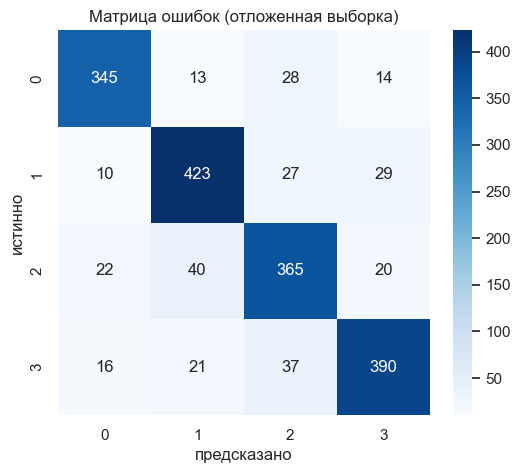

In [8]:
X_tr, X_val, y_tr, y_val = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)
model = make_full_model().fit(X_tr, y_tr)
pred_val = model.predict(X_val)
print(f"Holdout accuracy: {accuracy_score(y_val, pred_val):.4f}\n")
print(classification_report(y_val, pred_val))

cm = confusion_matrix(y_val, pred_val)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=[0,1,2,3], yticklabels=[0,1,2,3])
plt.title("Матрица ошибок (отложенная выборка)")
plt.xlabel("предсказано"); plt.ylabel("истинно"); plt.show()

## 7. Обучение на всех данных и submission

In [9]:
final_model = make_full_model().fit(X, y)
test_pred = final_model.predict(X_test)

submission = pd.DataFrame({"id": test["id"], "sleep_stage": test_pred})
assert list(submission.columns) == ["id", "sleep_stage"]
assert len(submission) == 5000
assert submission["sleep_stage"].isin([0,1,2,3]).all()

submission.to_csv("submission.csv", index=False)
print("Сохранено: submission.csv")
print(submission["sleep_stage"].value_counts().sort_index())
submission.head()

Сохранено: submission.csv
sleep_stage
0    1119
1    1292
2    1306
3    1283
Name: count, dtype: int64


,id,sleep_stage
0,9000,3
1,9001,3
2,9002,1
3,9003,2
4,9004,3


## 8. Итог

| Шаг | CV accuracy |
|---|---|
| dummy (пустышка) | 0.271 |
| логистическая регрессия | 0.749 |
| ансамбль деревьев (02) | 0.818 |
| + импутация eog_burst_index | 0.834 |
| + бустинги + доменные признаки (03) | 0.837 |
| + Optuna + стэкинг | 0.840 |
| **+ SVM-RBF (StandardScaler, C=2)** | **0.843** |

Это **надёжная финальная версия** — только проверенные на CV компоненты.
`submission.csv` готов — **заливаю на Kaggle вручную**.

**Что проверено и отброшено как шум/вред:** seed-averaging (ронял public),
расширенные доменные признаки, лаги/окна (нет временной структуры),
соотношения через деление (некорректны на z-score), hard voting, passthrough,
HGB-импутер. Модель на потолке данных (~0.844), подтверждено adversarial validation.

---
# 📎 Приложение: как работают ключевые части
*(справочный раздел для понимания и выступления — код выполнять не нужно)*

## A. Умная импутация — `IterativeImputer`

**Проблема:** `eog_burst_index` — сильнейший признак (corr с таргетом −0.40), но ~50% значений пропущено.
`fillna(0)` поставил бы константу половине строк и стёр сигнал.

**Идея (MICE):** пропущенный признак — это регрессия по остальным.
«Какое значение `eog_burst_index` логично при таких ЭЭГ, пульсе, дыхании?»

**Как восстанавливает:**
- линейный регрессор (BayesianRidge) обучается на строках, где значение известно;
- предсказывает пропуски; повторяет несколько итераций, уточняя.

**Качество:** спрятали 30% реальных значений → восстановили с **R² ≈ 0.87**, MAE 0.30.
R² = «доля разброса, которую модель объяснила» (1.0 — идеально, 0 — не лучше среднего).

**Без утечки:** импьютер внутри `Pipeline` → на каждом фолде учится только на train-части.

**Эффект:** 0.815 → 0.830 = **+0.014** — самый большой одиночный прирост в проекте.
*Вывод: чинить данные ценнее, чем усложнять модель.*

## B. SVM + StandardScaler

**SVM-RBF** проводит **кривые** границы между классами, измеряя **расстояния** между точками
(вокруг каждой — «гауссов колпак»). Это модель другой природы, чем деревья → полезна в стэке.

**Зачем StandardScaler:** раз SVM считает расстояния, признак с бо́льшим разбросом доминирует.
У нас разброс РАЗНЫЙ (std от 1.0 у `eog_burst_index` до 7.2 у `wake_idx`). Scaler приводит всё
к среднему 0 и std 1 → признаки весят одинаково.

| SVM | CV |
|---|---|
| без scaler | 0.828 |
| со StandardScaler | **0.836** (+0.9%) |

**Только вокруг SVM:** деревьям масштаб безразличен (режут по порогам) — проверено,
RandomForest со scaler и без даёт идентичный результат.

## C. Параметры SVM: ядро RBF, C, gamma

- **RBF-ядро** — гладкие кривые границы любой формы (сумма «колпаков» вокруг точек).
- **gamma** — ширина колпака. `"scale"` (авто) — лучший по перебору.
- **C** — строгость к ошибкам на обучении:
  - маленькое → гладкая простая граница (недообучение),
  - большое → огибает каждую точку (переобучение).

| C | 1 | **2** | 3 | 5 | 10 |
|---|---|---|---|---|---|
| CV | 0.836 | **0.837** | 0.836 | 0.832 | 0.826 |

C=2 — золотая середина; при C=10 видно переобучение (0.826).

## D. Стэкинг — почему умнее голосования

- **Голосование (voting):** усредняем ответы моделей поровну.
- **Стэкинг:** сверху мета-модель (логрегрессия), которая учится **кому верить в какой ситуации**
  — по out-of-fold предсказаниям базовых моделей.

| Подход | CV |
|---|---|
| hard voting | хуже (теряет уверенность) |
| soft voting (Cat+LGBM+XGB) | 0.837 |
| **стэкинг + SVM(scaler)** | **0.844** |

**Почему работает:** деревья и SVM ошибаются в **разных** местах → мета-модель использует
сильные стороны каждой. Мета = логрегрессия (HGB как мета переобучается: 0.827).